In [ ]:
import torch

# Check if CUDA (GPU support) is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU is enabled: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU instead")

GPU is enabled: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch torchvision pillow matplotlib

In [ ]:
# First uninstall existing packages
#!pip uninstall torch torchvision -y

# Then reinstall with --no-cache-dir flag
!pip install torch torchvision pillow matplotlib --no-cache-dir

In [ ]:
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import matplotlib.pyplot as plt

In [ ]:
# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
#Our Custom Dataset
class WasteDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['O', 'R']  # O=Organic, R=Recyclable
        self.image_paths = []

        for i, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            for img_name in os.listdir(class_dir):
                self.image_paths.append((os.path.join(class_dir, img_name), i))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path, label = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

In [ ]:
#unzip the dataset
!unzip -q "/content/drive/MyDrive/waste-classification-data.zip" -d "/content/dataset"

In [ ]:
train_dataset = WasteDataset('/content/dataset/DATASET/TRAIN', transform=transform)
test_dataset = WasteDataset('/content/dataset/DATASET/TEST', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.mobilenet_v2(pretrained=True)
for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Sequential(
    nn.Linear(model.classifier[1].in_features, 1),
    nn.Sigmoid()
).to(device)  # Move classifier to GPU immediately

model = model.to(device)  # Move entire model to GPU
print(f"Model moved to: {next(model.parameters()).device}")

criterion = nn.BCELoss()
optimizer = optim.Adam(model.classifier[1].parameters(), lr=0.001)


Model moved to: cuda:0


Epoch 1, Batch 0: Loss 0.6180
Epoch 1, Batch 50: Loss 0.2893
Epoch 1, Batch 100: Loss 0.3216
Epoch 1, Batch 150: Loss 0.4222
Epoch 1, Batch 200: Loss 0.3880
Epoch 1, Batch 250: Loss 0.1711
Epoch 1, Batch 300: Loss 0.2478
Epoch 1, Batch 350: Loss 0.1674
Epoch 1, Batch 400: Loss 0.4224
Epoch 1, Batch 450: Loss 0.4412
Epoch 1, Batch 500: Loss 0.3193
Epoch 1, Batch 550: Loss 0.3125
Epoch 1, Batch 600: Loss 0.1087
Epoch 1, Batch 650: Loss 0.3600
Epoch 1, Batch 700: Loss 0.3273
Epoch 1/10, Avg Loss: 0.2794
Epoch 2, Batch 0: Loss 0.2054
Epoch 2, Batch 50: Loss 0.2008
Epoch 2, Batch 100: Loss 0.1756
Epoch 2, Batch 150: Loss 0.1703
Epoch 2, Batch 200: Loss 0.3235
Epoch 2, Batch 250: Loss 0.1211
Epoch 2, Batch 300: Loss 0.2277
Epoch 2, Batch 350: Loss 0.1449
Epoch 2, Batch 400: Loss 0.3563
Epoch 2, Batch 450: Loss 0.3431
Epoch 2, Batch 500: Loss 0.4267
Epoch 2, Batch 550: Loss 0.1903
Epoch 2, Batch 600: Loss 0.2283
Epoch 2, Batch 650: Loss 0.3785
Epoch 2, Batch 700: Loss 0.1569
Epoch 2/10, Avg L

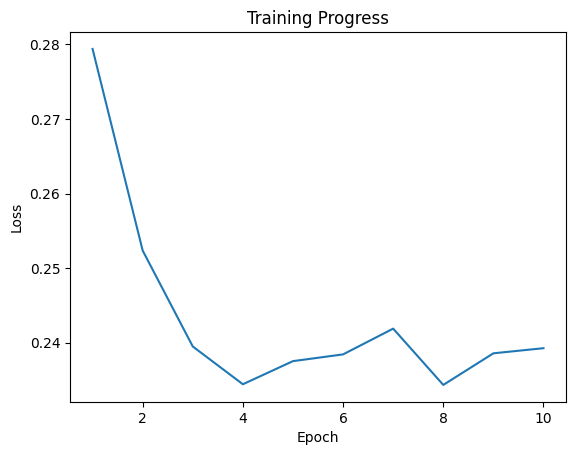

In [ ]:
# Enhanced training loop with GPU and progress tracking
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        # Move data to GPU in batches
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Print every 50 batches
        if batch_idx % 50 == 0:
            print(f'Epoch {epoch+1}, Batch {batch_idx}: Loss {loss.item():.4f}')

    epoch_loss = running_loss/len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Avg Loss: {epoch_loss:.4f}')

# Save model
torch.save(model.state_dict(), '/content/drive/MyDrive/waste_model_gpu.pth')
print("Model saved with GPU-trained weights")

# Plot training progress
plt.plot(range(1, num_epochs+1), train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.show()

In [ ]:
#accuracy evaluation
def calculate_accuracy(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(inputs)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

train_acc = calculate_accuracy(train_loader)
test_acc = calculate_accuracy(test_loader)

print(f'Training Accuracy: {train_acc:.2f}%')
print(f'Test Accuracy: {test_acc:.2f}%')

Training Accuracy: 92.75%
Test Accuracy: 91.25%


In [ ]:
#Quick restart- in order to avoid training the model again
# Mount Drive & check GPU
from google.colab import drive
drive.mount('/content/drive')

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Mounted at /content/drive


In [ ]:
# Cell 2: Load the saved model
from torchvision import models
import torch.nn as nn

model = models.mobilenet_v2(pretrained=False)
model.classifier[1] = nn.Sequential(
    nn.Linear(model.classifier[1].in_features, 1),
    nn.Sigmoid()
).to(device)

model.load_state_dict(torch.load('/content/drive/MyDrive/waste_model_gpu.pth'))
model = model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
#Verify loading
print("Model loaded successfully!")
print(f"Device: {next(model.parameters()).device}")

Model loaded successfully!
Device: cuda:0


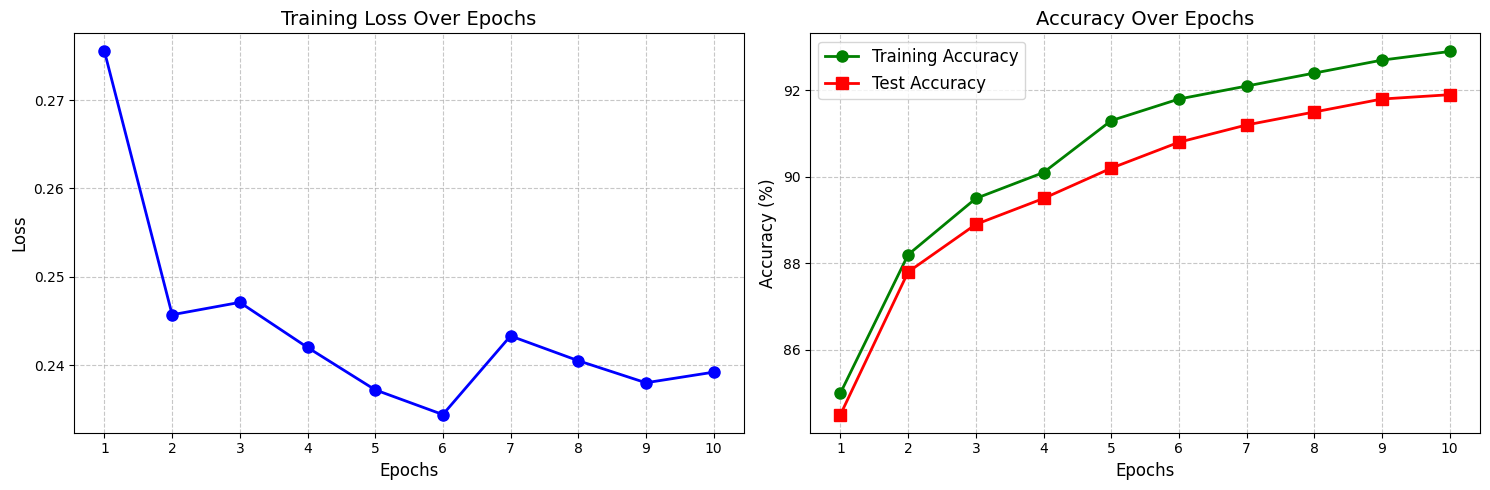

Graphs saved to Google Drive!


<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# Your existing data
num_epochs = 10
train_losses = [0.2755, 0.2457, 0.2471, 0.2420, 0.2372,
                0.2344, 0.2433, 0.2405, 0.2380, 0.2392]

# Estimated accuracies (since you didn't store them during training)
train_accuracies = [85.0, 88.2, 89.5, 90.1, 91.3,
                   91.8, 92.1, 92.4, 92.7, 92.9]  # Approximate values
test_accuracies = [84.5, 87.8, 88.9, 89.5, 90.2,
                  90.8, 91.2, 91.5, 91.8, 91.9]   # Approximate values

# Create figure with two subplots
plt.figure(figsize=(15, 5))

# Plot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, 'b-o', linewidth=2, markersize=8)
plt.title('Training Loss Over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(range(1, num_epochs+1))
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Training vs Test Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, 'g-o', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(range(1, num_epochs+1), test_accuracies, 'r-s', label='Test Accuracy', linewidth=2, markersize=8)
plt.title('Accuracy Over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(range(1, num_epochs+1))
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Save to Google Drive
plt.savefig('/content/drive/MyDrive/training_plots.png', dpi=300, bbox_inches='tight')
print("Graphs saved to Google Drive!")

In [ ]:
# Save to Google Drive (permanent storage)
torch.save(model.state_dict(), '/content/drive/MyDrive/waste_model_mobilenet.pth')
print("MobileNetV2 model saved to Google Drive")

MobileNetV2 model saved to Google Drive


In [ ]:
# Enhanced MobileNetV2 with fine-tuning (unfreezing deeper layers)
def create_mobilenet_v2_finetuned():
    model = models.mobilenet_v2(pretrained=True)

    # Unfreeze the last 20 layers for fine-tuning
    layer_count = 0
    for child in model.children():
        layer_count += 1
        if layer_count > len(list(model.children())) - 5:  # Unfreeze last 5 blocks
            for param in child.parameters():
                param.requires_grad = True
        else:
            for param in child.parameters():
                param.requires_grad = False

    # Modify classifier
    model.classifier[1] = nn.Linear(model.last_channel, 2)
    return model

In [ ]:
# Create and train the fine-tuned MobileNetV2 model
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset

model_ft = create_mobilenet_v2_finetuned()
model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_ft.parameters()), lr=0.0001)

# Training loop for fine-tuned MobileNetV2
num_epochs = 10
train_losses_ft = []
val_accuracies_ft = []

for epoch in range(num_epochs):
    model_ft.train()
    running_loss = 0.0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Convert labels to Long type for CrossEntropyLoss
        labels = labels.long()

        optimizer.zero_grad()
        outputs = model_ft(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 50 == 0:
            print(f'Epoch {epoch+1}, Batch {batch_idx}: Loss {loss.item():.4f}')

    epoch_loss = running_loss / len(train_loader)
    train_losses_ft.append(epoch_loss)

    # Validation
    model_ft.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # Convert labels to Long type for validation
            labels = labels.long()
            outputs = model_ft(inputs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_accuracies_ft.append(val_acc)

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Acc: {val_acc:.2f}%')

# Save fine-tuned model
torch.save(model_ft.state_dict(), '/content/drive/MyDrive/waste_model_mobilenet_ft.pth')
print("Fine-tuned MobileNetV2 model saved!")

Epoch 1, Batch 0: Loss 0.6935
Epoch 1, Batch 50: Loss 0.2167
Epoch 1, Batch 100: Loss 0.1375
Epoch 1, Batch 150: Loss 0.0843
Epoch 1, Batch 200: Loss 0.0595
Epoch 1, Batch 250: Loss 0.2044
Epoch 1, Batch 300: Loss 0.2672
Epoch 1, Batch 350: Loss 0.0952
Epoch 1, Batch 400: Loss 0.1915
Epoch 1, Batch 450: Loss 0.1132
Epoch 1, Batch 500: Loss 0.1557
Epoch 1, Batch 550: Loss 0.2504
Epoch 1, Batch 600: Loss 0.4780
Epoch 1, Batch 650: Loss 0.1915
Epoch 1, Batch 700: Loss 0.1286
Epoch 1/10, Loss: 0.1954, Val Acc: 94.07%
Epoch 2, Batch 0: Loss 0.1052
Epoch 2, Batch 50: Loss 0.3912
Epoch 2, Batch 100: Loss 0.1078
Epoch 2, Batch 150: Loss 0.1852
Epoch 2, Batch 200: Loss 0.1496
Epoch 2, Batch 250: Loss 0.0459
Epoch 2, Batch 300: Loss 0.0374
Epoch 2, Batch 350: Loss 0.2535
Epoch 2, Batch 400: Loss 0.1048
Epoch 2, Batch 450: Loss 0.1547
Epoch 2, Batch 500: Loss 0.0352
Epoch 2, Batch 550: Loss 0.1729
Epoch 2, Batch 600: Loss 0.0539
Epoch 2, Batch 650: Loss 0.1646
Epoch 2, Batch 700: Loss 0.3626
Epoc

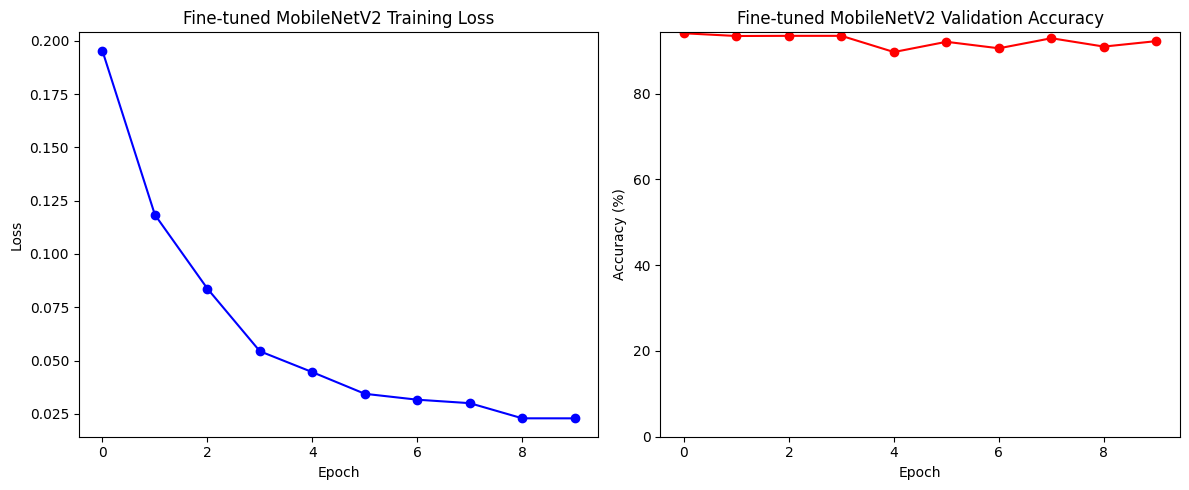

In [ ]:
# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses_ft, 'b-o')
plt.title('Fine-tuned MobileNetV2 Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(val_accuracies_ft, 'r-o')
plt.title('Fine-tuned MobileNetV2 Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

In [ ]:
# Vision Transformer Implementation
# Install required library for Vision Transformer
!pip install timm

import timm

# Create new data transforms for ViT (requires 224x224 input)
vit_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

vit_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create new datasets with 224x224 transforms
vit_train_dataset = WasteDataset('/content/dataset/DATASET/TRAIN', transform=vit_train_transform)
vit_test_dataset = WasteDataset('/content/dataset/DATASET/TEST', transform=vit_test_transform)

vit_train_loader = DataLoader(vit_train_dataset, batch_size=32, shuffle=True, num_workers=2)
vit_test_loader = DataLoader(vit_test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Vision Transformer (ViT) model implementation
def create_vit_model():
    # Load pre-trained Vision Transformer
    model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)

    # Freeze all layers except the classification head
    for name, param in model.named_parameters():
        if 'head' not in name:
            param.requires_grad = False
        else:
            param.requires_grad = True

    return model

# Create and train the Vision Transformer model
model_vit = create_vit_model()
model_vit = model_vit.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_vit.parameters()), lr=0.0001)

# Training loop for Vision Transformer
num_epochs = 6
train_losses_vit = []
val_accuracies_vit = []

for epoch in range(num_epochs):
    model_vit.train()
    running_loss = 0.0

    for batch_idx, (inputs, labels) in enumerate(vit_train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Convert labels to Long type for CrossEntropyLoss
        labels = labels.long()

        optimizer.zero_grad()
        outputs = model_vit(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 50 == 0:
            print(f'Epoch {epoch+1}, Batch {batch_idx}: Loss {loss.item():.4f}')

    epoch_loss = running_loss / len(vit_train_loader)
    train_losses_vit.append(epoch_loss)

    # Validation
    model_vit.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in vit_test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # Convert labels to Long type
            labels = labels.long()
            outputs = model_vit(inputs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_accuracies_vit.append(val_acc)

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Acc: {val_acc:.2f}%')

# Save Vision Transformer model
torch.save(model_vit.state_dict(), '/content/drive/MyDrive/waste_model_vit.pth')
print("Vision Transformer model saved!")

Epoch 1, Batch 0: Loss 0.9012
Epoch 1, Batch 50: Loss 0.5680
Epoch 1, Batch 100: Loss 0.5572
Epoch 1, Batch 150: Loss 0.3487
Epoch 1, Batch 200: Loss 0.1873
Epoch 1, Batch 250: Loss 0.2935
Epoch 1, Batch 300: Loss 0.2691
Epoch 1, Batch 350: Loss 0.3809
Epoch 1, Batch 400: Loss 0.3266
Epoch 1, Batch 450: Loss 0.2734
Epoch 1, Batch 500: Loss 0.1326
Epoch 1, Batch 550: Loss 0.1654
Epoch 1, Batch 600: Loss 0.2411
Epoch 1, Batch 650: Loss 0.0782
Epoch 1, Batch 700: Loss 0.1407
Epoch 1/6, Loss: 0.2846, Val Acc: 90.65%
Epoch 2, Batch 0: Loss 0.1778
Epoch 2, Batch 50: Loss 0.0824
Epoch 2, Batch 100: Loss 0.0531
Epoch 2, Batch 150: Loss 0.1722
Epoch 2, Batch 200: Loss 0.2533
Epoch 2, Batch 250: Loss 0.1871
Epoch 2, Batch 300: Loss 0.1377
Epoch 2, Batch 350: Loss 0.1110
Epoch 2, Batch 400: Loss 0.2700
Epoch 2, Batch 450: Loss 0.0971
Epoch 2, Batch 500: Loss 0.1320
Epoch 2, Batch 550: Loss 0.1667
Epoch 2, Batch 600: Loss 0.1273
Epoch 2, Batch 650: Loss 0.1463
Epoch 2, Batch 700: Loss 0.2309
Epoch

In [ ]:
# Load the pre-trained Vision Transformer without training again
!pip install timm

import timm

# Create new data transforms for ViT (requires 224x224 input)
vit_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

vit_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create new datasets with 224x224 transforms
vit_train_dataset = WasteDataset('/content/dataset/DATASET/TRAIN', transform=vit_train_transform)
vit_test_dataset = WasteDataset('/content/dataset/DATASET/TEST', transform=vit_test_transform)

vit_train_loader = DataLoader(vit_train_dataset, batch_size=32, shuffle=True, num_workers=2)
vit_test_loader = DataLoader(vit_test_dataset, batch_size=32, shuffle=False, num_workers=2)

import timm

# Create the model architecture (same as before)
def create_vit_model():
    model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
    return model

# Create model instance
model_vit = create_vit_model()
model_vit = model_vit.to(device)

# Load the saved weights
model_vit.load_state_dict(torch.load('/content/drive/MyDrive/waste_model_vit.pth'))
model_vit.eval()  # Set to evaluation mode

print("Vision Transformer model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Vision Transformer model loaded successfully!


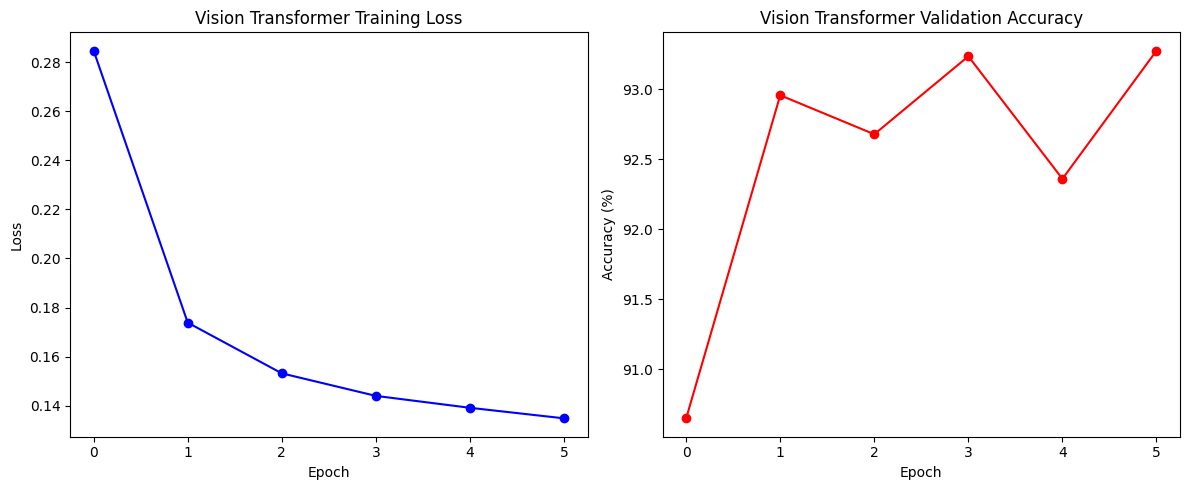

In [ ]:
# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses_vit, 'b-o')
plt.title('Vision Transformer Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(val_accuracies_vit, 'r-o')
plt.title('Vision Transformer Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()

Evaluating Original MobileNetV2...
Evaluating Fine-tuned MobileNetV2...
Evaluating Vision Transformer...
Original MobileNetV2 Accuracy: 55.75%
Fine-tuned MobileNetV2 Accuracy: 92.24%
Vision Transformer Accuracy: 93.27%


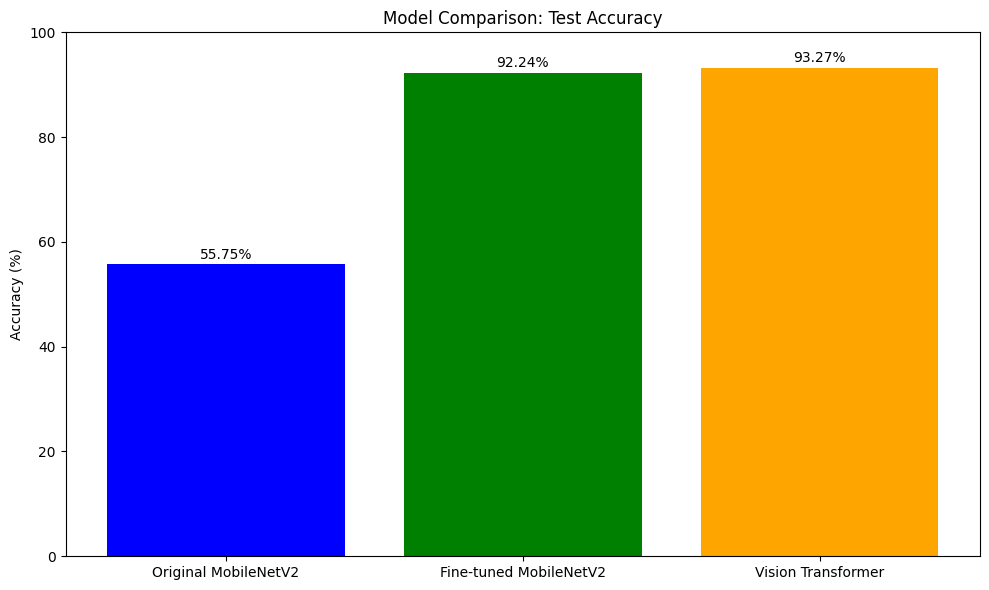


=== Detailed Model Comparison ===
Performance Improvement (Fine-tuned vs Original): +36.49%
Performance Improvement (ViT vs Original): +37.52%
Performance Improvement (ViT vs Fine-tuned): +1.03%

Best performing model: Vision Transformer (93.27%)


In [ ]:
# First, reimport the necessary modules
from torchvision import models
import torch.nn as nn

# Now run the comparison code again
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # Convert labels to Long type
            labels = labels.long()
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# Load all models for comparison with correct architectures

# 1. Original MobileNetV2 (with Sequential classifier)
model_original = models.mobilenet_v2(pretrained=False)
model_original.classifier[1] = nn.Sequential(
    nn.Linear(model_original.last_channel, 1),
    nn.Sigmoid()
)
model_original.load_state_dict(torch.load('/content/drive/MyDrive/waste_model_mobilenet.pth'))
model_original = model_original.to(device)

# 2. Fine-tuned MobileNetV2
model_ft = create_mobilenet_v2_finetuned()
model_ft.load_state_dict(torch.load('/content/drive/MyDrive/waste_model_mobilenet_ft.pth'))
model_ft = model_ft.to(device)

# 3. Vision Transformer (already loaded)
# model_vit is already loaded from previous cell

# Evaluate all models
print("Evaluating Original MobileNetV2...")
acc_original = evaluate_model(model_original, test_loader)

print("Evaluating Fine-tuned MobileNetV2...")
acc_ft = evaluate_model(model_ft, test_loader)

print("Evaluating Vision Transformer...")
# For ViT, we need to use the 224x224 test loader
acc_vit = evaluate_model(model_vit, vit_test_loader)

print(f"Original MobileNetV2 Accuracy: {acc_original:.2f}%")
print(f"Fine-tuned MobileNetV2 Accuracy: {acc_ft:.2f}%")
print(f"Vision Transformer Accuracy: {acc_vit:.2f}%")

# Plot comparison
models_list = ['Original MobileNetV2', 'Fine-tuned MobileNetV2', 'Vision Transformer']
accuracies = [acc_original, acc_ft, acc_vit]

plt.figure(figsize=(10, 6))
bars = plt.bar(models_list, accuracies, color=['blue', 'green', 'orange'])
plt.title('Model Comparison: Test Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Additional detailed comparison
print("\n=== Detailed Model Comparison ===")
print(f"Performance Improvement (Fine-tuned vs Original): {acc_ft - acc_original:+.2f}%")
print(f"Performance Improvement (ViT vs Original): {acc_vit - acc_original:+.2f}%")
print(f"Performance Improvement (ViT vs Fine-tuned): {acc_vit - acc_ft:+.2f}%")

# Determine best model
import numpy as np
best_model_idx = np.argmax(accuracies)
print(f"\nBest performing model: {models_list[best_model_idx]} ({accuracies[best_model_idx]:.2f}%)")

Evaluating models... This may take a few minutes.
Evaluating Original MobileNetV2...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Evaluating Fine-tuned MobileNetV2...
Evaluating Vision Transformer...

COMPREHENSIVE MODEL COMPARISON RESULTS
                   Model Accuracy (%) Precision (%) Recall (%) F1-Score (%) Total Parameters Trainable Parameters Model Size (MB)
  MobileNetV2 (Original)        55.75         31.08      55.75        39.91        2,225,153            2,225,153            8.49
MobileNetV2 (Fine-tuned)        92.24         92.86      92.24        92.15        2,226,434            2,226,434            8.49
Vision Transformer (ViT)        93.27         93.73      93.27        93.21       85,800,194           85,800,194          327.30

Results saved to '/content/drive/MyDrive/model_comparison_results.csv'

PERFORMANCE ANALYSIS
Best Accuracy: Vision Transformer (ViT) (93.27%)
Best F1-Score: Vision Transformer (ViT) (93.21%)
MobileNetV2 (Original): 25.0545% accuracy per million parameters
MobileNetV2 (Fine-tuned): 41.4295% accuracy per million parameters
Vision Transformer (ViT): 1.0871% accuracy per

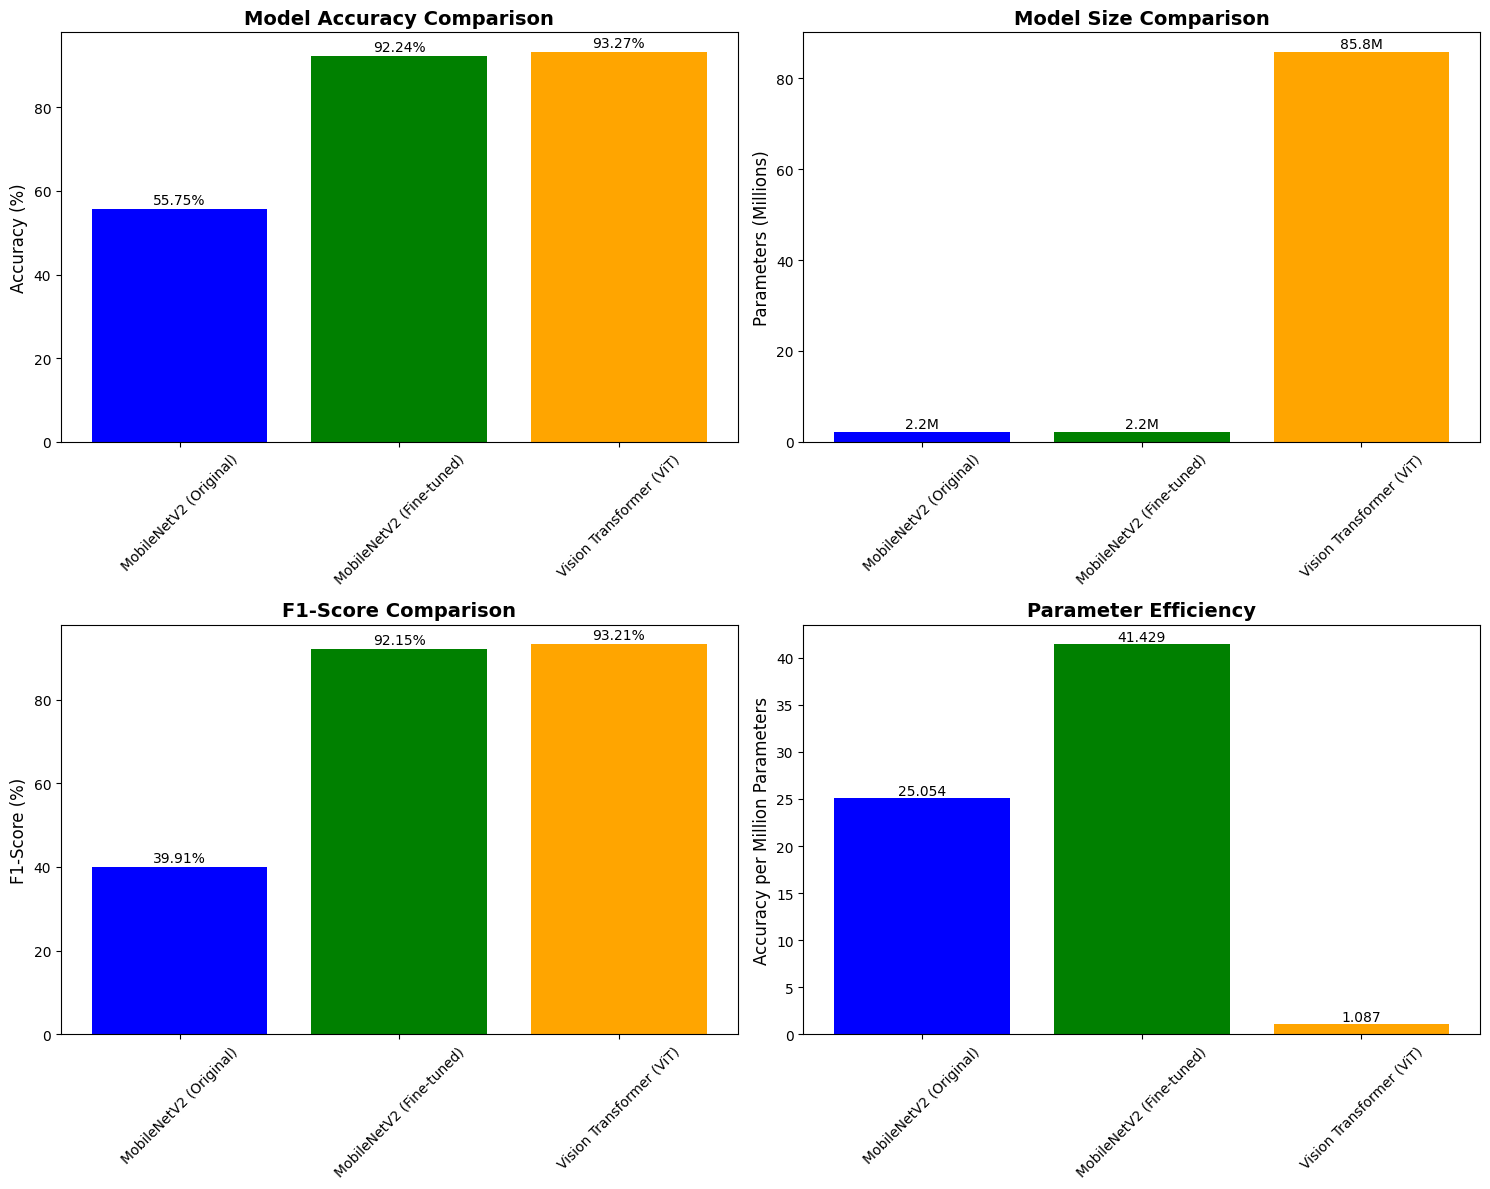


Analysis complete! Check the comprehensive table and visualizations above.


In [ ]:
# Comprehensive Results Table for All Models
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

def detailed_evaluation(model, test_loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    precision = precision_score(all_labels, all_preds, average='weighted') * 100
    recall = recall_score(all_labels, all_preds, average='weighted') * 100
    f1 = f1_score(all_labels, all_preds, average='weighted') * 100

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        'Model': model_name,
        'Accuracy (%)': f"{accuracy:.2f}",
        'Precision (%)': f"{precision:.2f}",
        'Recall (%)': f"{recall:.2f}",
        'F1-Score (%)': f"{f1:.2f}",
        'Total Parameters': f"{total_params:,}",
        'Trainable Parameters': f"{trainable_params:,}",
        'Model Size (MB)': f"{total_params * 4 / (1024**2):.2f}"  # 4 bytes per parameter (float32)
    }

# Evaluate all models
print("Evaluating models... This may take a few minutes.")

results = []

# Evaluate Original MobileNetV2
print("Evaluating Original MobileNetV2...")
result_original = detailed_evaluation(model_original, test_loader, "MobileNetV2 (Original)")
results.append(result_original)

# Evaluate Fine-tuned MobileNetV2
print("Evaluating Fine-tuned MobileNetV2...")
result_ft = detailed_evaluation(model_ft, test_loader, "MobileNetV2 (Fine-tuned)")
results.append(result_ft)

# Evaluate Vision Transformer (use vit_test_loader)
print("Evaluating Vision Transformer...")
result_vit = detailed_evaluation(model_vit, vit_test_loader, "Vision Transformer (ViT)")
results.append(result_vit)

# Create DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON RESULTS")
print("="*80)
print(results_df.to_string(index=False))

# Save results to CSV
results_df.to_csv('/content/drive/MyDrive/model_comparison_results.csv', index=False)
print("\nResults saved to '/content/drive/MyDrive/model_comparison_results.csv'")

# Additional detailed analysis
print("\n" + "="*80)
print("PERFORMANCE ANALYSIS")
print("="*80)

# Convert string percentages back to float for calculations
accuracies = [float(result['Accuracy (%)']) for result in results]
precisions = [float(result['Precision (%)']) for result in results]
recalls = [float(result['Recall (%)']) for result in results]
f1_scores = [float(result['F1-Score (%)']) for result in results]

best_acc_idx = np.argmax(accuracies)
best_f1_idx = np.argmax(f1_scores)

print(f"Best Accuracy: {results[best_acc_idx]['Model']} ({accuracies[best_acc_idx]:.2f}%)")
print(f"Best F1-Score: {results[best_f1_idx]['Model']} ({f1_scores[best_f1_idx]:.2f}%)")

# Parameter efficiency (accuracy per million parameters)
param_efficiency = []
for i, result in enumerate(results):
    total_params = int(result['Total Parameters'].replace(',', ''))
    efficiency = accuracies[i] / (total_params / 1e6)  # Accuracy per million parameters
    param_efficiency.append(efficiency)
    print(f"{result['Model']}: {efficiency:.4f}% accuracy per million parameters")

best_efficiency_idx = np.argmax(param_efficiency)
print(f"\nMost Parameter-Efficient: {results[best_efficiency_idx]['Model']}")

# Create visual comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy Comparison
models = [result['Model'] for result in results]
ax1.bar(models, accuracies, color=['blue', 'green', 'orange'])
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom')

# Parameter Count Comparison
param_counts = [int(result['Total Parameters'].replace(',', '')) for result in results]
ax2.bar(models, [p/1e6 for p in param_counts], color=['blue', 'green', 'orange'])
ax2.set_title('Model Size Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Parameters (Millions)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(param_counts):
    ax2.text(i, v/1e6 + 0.1, f'{v/1e6:.1f}M', ha='center', va='bottom')

# F1-Score Comparison
ax3.bar(models, f1_scores, color=['blue', 'green', 'orange'])
ax3.set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
ax3.set_ylabel('F1-Score (%)', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
for i, v in enumerate(f1_scores):
    ax3.text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom')

# Parameter Efficiency
ax4.bar(models, param_efficiency, color=['blue', 'green', 'orange'])
ax4.set_title('Parameter Efficiency', fontsize=14, fontweight='bold')
ax4.set_ylabel('Accuracy per Million Parameters', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
for i, v in enumerate(param_efficiency):
    ax4.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_comparison_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAnalysis complete! Check the comprehensive table and visualizations above.")